In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assignment 1
from scipy.interpolate import lagrange, interp1d
from scipy.optimize import fsolve
from utils import lagrange_basis, lagrange_interp, newton

# Assignment 2
from math import dist

# Assignment 3
from scipy import sparse
from skimage import data, img_as_float, transform
from scipy.signal import convolve2d
from scipy.sparse.linalg import splu, spsolve
from utils import jacobi, gauss_seidel, conj_gradient
from sklearn.metrics import mean_squared_error

# Final project for the course of Applied Math: numerical analysis and scientific computing, academic year 2025-26

## Assignments
### Assignment 1: The discharge cycle of a lithium-ion battery.

NASA provides some databases to study the charge and discharge cycles of a lithium-ion battery.
We provide in CSV format the data containing:
- the time $t$ associated with a discarge cycle (measured in seconds),
- the voltage $V$ associated with the time instances,
- the current $I$ associated with the time instances.
- The data are in `data_assignment1/battery_discharge.csv`.

**Tasks**:
1. Read the data in the CSV file using `pandas` and plot the voltage against time.
2. Interpolation task:
    - Estimate the voltage at times 500, 1500, 2500 seconds using **Lagrange interpolation** using different equispaced downsamplings of the data (one point every 5, 10, ecc). This corresponds to varying the number of nodes, and hence, the degree of the fitting polynomial.
    - Compare the results with the built-in scipy function `scipy.interpolate.lagrange`;
    - Extrapolation: if we only use data in the time window $[0, 3100]$, how does the interpolation performs at $t=3300$?
    - **Bonus**: are we able to improve the Lagrange interpolation, considering as data all the data points in $[0, 3100]$ by using other interpolation approaches? Which is the method with the closest prediction at $t=3300$?
    *Hint*: explore the functions in `scipy.interpolate`. 
3. Regression task:
    - Fit the model: $$V(t) = V_0 + a t + b t^2 + ct^3$$
    using data in time interval $[0, 3100]$. Is the least-squares fitting polynomial performing better than the interpolation approaches you have seen?
4. Find the time $t^{\star}$ such that:
    $V(t^{\star}) = 3.6,$ where $V(t)$ is approximated with one of the interpolation techniques you used before.

---


## SOLUTION


### 1.
Reading the data from the CSV file with `pandas`

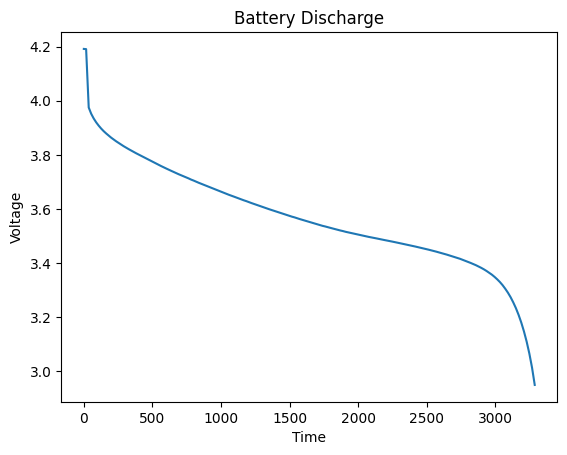

In [20]:
df = pd.read_csv("battery_discharge.csv")
# Plotting the voltage against time with matplotlib
plt.plot(df["time"], df["voltage"])
plt.xlabel("Time")
plt.ylabel("Voltage")
plt.title("Battery Discharge")
plt.show()

### 2.

In [21]:

# Time values to estimate the voltage at
time_values = np.array([500, 1500, 2500])

# I choose different numbers of nodes to see how the interpolation changes with more or less points
downsampling_steps = [5, 10, 20, 50, 100]
results = {}

for steps in downsampling_steps:
    # Downsample the data
    indices = np.linspace(0, len(df) - 1, steps).astype(int)

    X_nodes = df["time"].iloc[indices].values
    Y_nodes = df["voltage"].iloc[indices].values
    
    # Interpolate the voltage at the specified time values with the Lagrange interpolation method (imported from utils.py)
    interpolated_voltages = lagrange_interp(X_nodes, Y_nodes, time_values)
    
    # Store the results in a dictionary
    name = f"interpolated_voltages_with_{steps}_nodes"
    results[name] = interpolated_voltages
print(results)

{'interpolated_voltages_with_5_nodes': array([3.83611825, 3.56610725, 3.4416219 ]), 'interpolated_voltages_with_10_nodes': array([3.77185011, 3.57429848, 3.45098194]), 'interpolated_voltages_with_20_nodes': array([3.77453569, 3.57410494, 3.45096564]), 'interpolated_voltages_with_50_nodes': array([3.8300974 , 3.57421298, 3.44249776]), 'interpolated_voltages_with_100_nodes': array([-6.74906191e+04,  3.57399480e+00,  2.44055818e+00])}


For the comparison I choose the value calculated with 10 nodes

In [22]:
interpolated_voltages_lagrange = results["interpolated_voltages_with_10_nodes"]
print("Interpolated voltages with Lagrange interpolation (10 nodes):", interpolated_voltages_lagrange)

Interpolated voltages with Lagrange interpolation (10 nodes): [3.77185011 3.57429848 3.45098194]


Results with `scipy` :

In [23]:
# Choosing 10 nodes
indices = np.linspace(0, len(df) - 1, 10).astype(int)
X_nodes = df["time"].iloc[indices].values
Y_nodes = df["voltage"].iloc[indices].values

# Using scipy's lagrange function for interpolation
poly_scipy = lagrange(X_nodes, Y_nodes)
interpolated_voltages_scipy = poly_scipy(time_values)
print(f"Interpolated voltages using scipy: {interpolated_voltages_scipy}")

Interpolated voltages using scipy: [3.77185011 3.57429848 3.45098194]


Comparison of the results

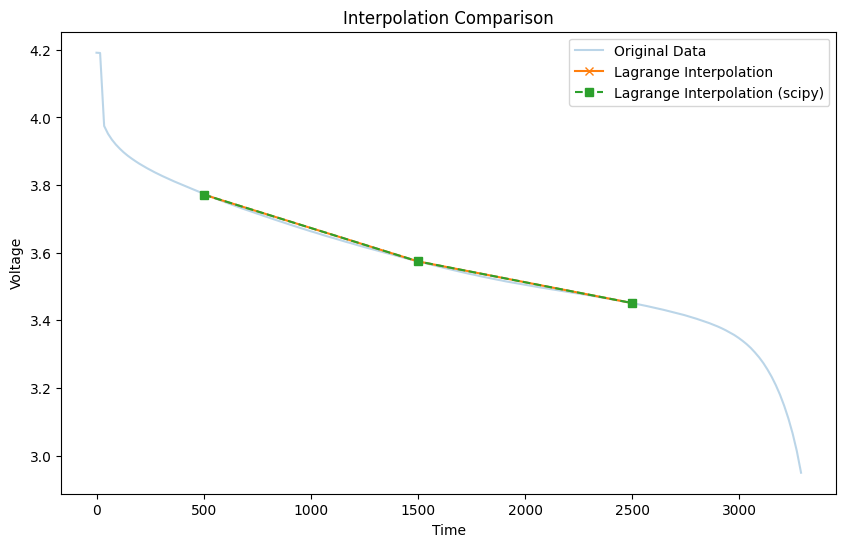

In [24]:
# Plotting results
plt.figure(figsize=(10, 6))
plt.plot(df["time"], df["voltage"], label="Original Data", alpha=0.3)
plt.plot(time_values, interpolated_voltages_lagrange, label="Lagrange Interpolation", marker="x")
plt.plot(
    time_values,
    interpolated_voltages_scipy,
    label="Lagrange Interpolation (scipy)",
    marker="s", linestyle='--'
)
plt.xlabel("Time")
plt.ylabel("Voltage")
plt.title("Interpolation Comparison")
plt.legend()
plt.show()

Using only data in [0,3100] as required for extrapolation at t=3300

In [25]:
df_extrap = df[df["time"] <= 3100]

# Time value to extrapolate the voltage at
time_value = 3300
extrapolated_voltage_lagrange = lagrange_interp(X_nodes, Y_nodes, np.array([time_value]))
print(f"Extrapolated voltage at time {time_value}: {extrapolated_voltage_lagrange[0]}")

Extrapolated voltage at time 3300: 2.912992132996832


BONUS: comparing with scipy interp1d

Linear interpolation using scipy: 2.9358544764099945
Cubic interpolation using scipy: 2.9254279821496096


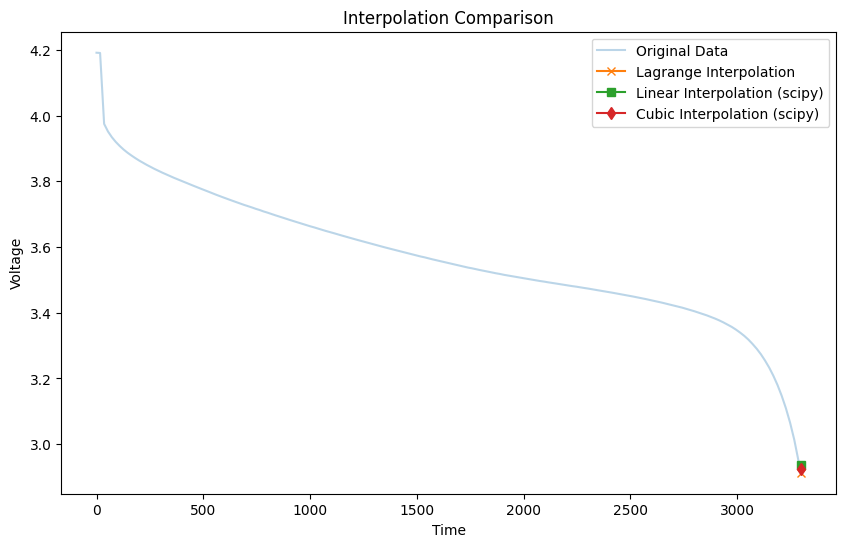

In [26]:
f_linear = interp1d(X_nodes, Y_nodes, kind="linear", fill_value="extrapolate")
f_cubic = interp1d(X_nodes, Y_nodes, kind="cubic", fill_value="extrapolate")

extrapolated_voltage_linear = f_linear([time_value])
extrapolated_voltage_cubic = f_cubic([time_value])

print(f"Linear interpolation using scipy: {extrapolated_voltage_linear[0]}")
print(f"Cubic interpolation using scipy: {extrapolated_voltage_cubic[0]}")

# Plotting results
plt.figure(figsize=(10, 6))
plt.plot(df["time"], df["voltage"], label="Original Data", alpha=0.3)
plt.plot(time_value, extrapolated_voltage_lagrange, label="Lagrange Interpolation", marker="x")
plt.plot(time_value, extrapolated_voltage_linear, label="Linear Interpolation (scipy)", marker="s")
plt.plot(time_value, extrapolated_voltage_cubic, label="Cubic Interpolation (scipy)", marker="d")
plt.xlabel("Time")
plt.ylabel("Voltage")
plt.title("Interpolation Comparison")
plt.legend()
plt.show()

We see from the plot that the closest method is the Lagrange interpolation

### 3.

In [27]:
# Using data in the interval [0, 3100]
df_reg = df[df["time"] <= 3100]
time_reg = df_reg["time"].values
voltage_reg = df_reg["voltage"].values
n = len(time_reg)

# Create the matrix
B = np.matrix([np.ones(n), time_reg, time_reg**2, time_reg**3]).T

# Calculate the coefficients
coeff = np.linalg.solve(B.T @ B, B.T @ np.matrix(voltage_reg).T)
print("Coefficients:", coeff)

# Define the model function (regression)
poly_reg = (
    lambda x: coeff[0, 0] + coeff[1, 0] * x + coeff[2, 0] * x**2 + coeff[3, 0] * x**3
)
predicted_voltage = poly_reg(time_value)
print(f"Predicted voltage at time {time_value} using regression: {predicted_voltage}")


Coefficients: [[ 3.99617552e+00]
 [-5.31504699e-04]
 [ 2.26552616e-07]
 [-4.05470721e-11]]
Predicted voltage at time 3300 using regression: 3.252227874377766


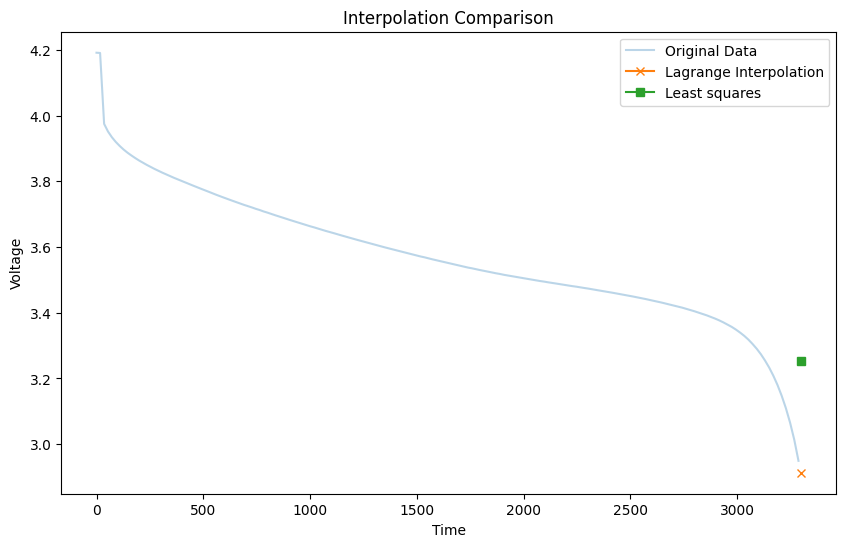

In [28]:
# Plotting results
plt.figure(figsize=(10, 6))
plt.plot(df["time"], df["voltage"], label="Original Data", alpha=0.3)
plt.plot(time_value, extrapolated_voltage_lagrange, label="Lagrange Interpolation", marker="x")
plt.plot(time_value, predicted_voltage, label="Least squares", marker="s")
plt.xlabel("Time")
plt.ylabel("Voltage")
plt.title("Interpolation Comparison")
plt.legend()
plt.show()

The Lagange interpolation is performing better
### 4.

In [29]:
# Find the time t* such that: V(t*)=3.6 where V(t) is approximated with one of the interpolation techniques you used before.
voltage_value = 3.6
# Using the regression model
# Newton's method to find the root
poly_reg_prime = lambda x: coeff[1, 0] + 2 * coeff[2, 0] * x + 3 * coeff[3, 0] * x**2
poly_reg_minus_v = lambda x: poly_reg(x) - voltage_value

t_star_reg = newton(poly_reg_minus_v, poly_reg_prime, x0=3000, eps=1e-8, n_max=100)
print(f"Time t* such that V(t*)=3.6 using regression: {t_star_reg[0]}")

Time t* such that V(t*)=3.6 using regression: 1293.3428263671801


## Assignment 2: Predict Airbnb Prices with Linear Regression From Scratch
Airbnb provides public and downloadable databases at https://insideairbnb.com with the data related to rooms (prices, room type, number of reviews, distance to center, etc).

Choose a city and complete the following tasks.
You can either choose one city in the folder `data_assignment2` or choose another city directly from the database.

**Tasks**:
1. Read the data using `pandas`, and in particular the data related to price, latitude, longitude,
  number of reviews, room type.
2. Analyze the dependency of the price with respect to different variables:
- distance from center $d$; 
- number of reviews $r$;
- room type $t$.

*Hint*: compute the distance from the city center based on the latitude and longitude (you can find the latitude and longitude of a city center online or from Google Maps).

  **2a.** Start from considering the price only as a linear or quadratic function of the distance from the city center $p(d)=c_0+c_1 d$ or $p(d)=c_0 + c_1 d +c_2 d^2$. Build the matrix $A$ and solve $$\min_{c} \|Ac-p\|_2, $$  where $c$ is the vector of coefficients via:
  - normal equations,
  - $QR$ factorization.

  Plot the approximated $p$ as a function of $d$ for different room types.

  **2b.** How is the conditioning of $A^T A$? How can we improve it?

  **2c.** Now consider only the number of reviews, and we want the price only dependent on it, namely $p(r)$. Repeat the same procedure as in (2a). Is your model better approximating the price? Is it better if you consider separately different room types $t$?
  Plot the approximated $p$ as a function of $r$ for different room types.

  *Hint*: compare the models in terms of the residual $\|Ac-p\|_2$.

  *Hint*: consider solving different systems for different room types.

  **2d.** Consider $p \sim p(d, r, t)$ and fit a least squares problem. Is this approximation more accurate than in the cases $p(d)$ and $p(r)$? Plot the approximated and the exact $p$ as a function of $d$ and $r$ for different room types.

**Final remark**: don't forget you are dealing with real and complex data, so it is hard to obtain good results. The important thing is that you justify your choices and the logic behind the solution you provide.

## SOLUTION

### 1.

In [30]:
# Reading the data from the CSV file
data_types = ["price", "latitude", "longitude", "number_of_reviews", "room_type"]
df_airbnb = pd.read_csv("airbnb_listings.csv", usecols=data_types)

### 2a.

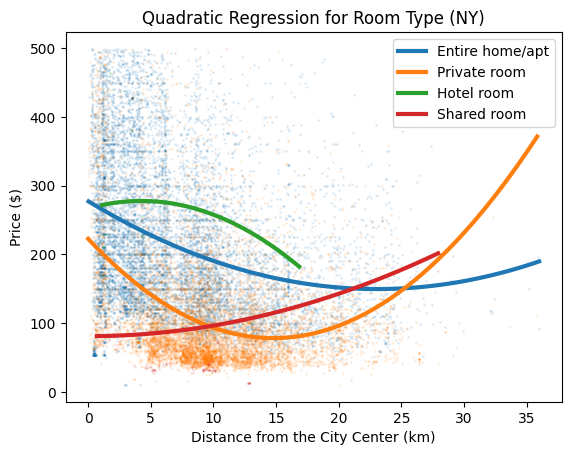

In [31]:
# Filtering listings with price greater than $500 (to see the plot better)
df_airbnb = df_airbnb[df_airbnb["price"] < 500]

price = df_airbnb["price"].values
n = len(price)  # Number of data points

# Selecting room types available in the data
room_types = df_airbnb["room_type"].unique()

# calculating the distance of each listing from the city center

# Times Square coordinates (NY city center)
latitude_center, longitude_center = 40.7580, -73.9855

# Euclid distance in km
# 1 degree of Latitude in NYC ≈ 111 km
# 1 degree of Longitude in NYC (at 40° latitude) ≈ 85 km
df_airbnb["distance"] = np.sqrt(
    ((df_airbnb["latitude"] - latitude_center) * 111) ** 2
    + ((df_airbnb["longitude"] - longitude_center) * 85) ** 2
)

dist_residuals = []

for rt in room_types:
    # Select the data for the current room type
    df_sub = df_airbnb[df_airbnb["room_type"] == rt]

    d = df_sub["distance"].values
    p = df_sub["price"].values
    n = len(d)

    # Create the matrix B (Quadratic: [1, d, d^2])
    B = np.column_stack([np.ones(n), d, d**2])

    # method 1: normal equations
    u_normal = np.linalg.solve(B.T @ B, B.T @ p)

    # method 2: QR factorization
    Q, R = np.linalg.qr(B)
    u_qr = np.linalg.solve(R, Q.T @ p)

    # Using the coefficients from the QR factorization to plot the curve
    x_axis = np.linspace(d.min(), d.max(), 100)
    y_poly = u_qr[0] + u_qr[1] * x_axis + u_qr[2] * (x_axis**2)

    # Plot the polynomial curve for the current room type
    plt.plot(x_axis, y_poly, label=f"{rt}", linewidth=3)
    # Scattering the real data points with low opacity
    plt.scatter(d, p, s=1, alpha=0.1)

    res = np.linalg.norm(B @ u_qr - p)
    dist_residuals.append(res)

plt.xlabel("Distance from the City Center (km)")
plt.ylabel("Price ($)")
plt.title("Quadratic Regression for Room Type (NY)")
plt.legend()
plt.show()

We can't see an obvious relation between prices and distance because the price depend on too many factors.

### 2b.

In [32]:
# Calculate the condition number of B.T @ B using numpy's linalg.cond function
cond_number = np.linalg.cond(B.T @ B)
print(f"Condition Number of B.T @ B: {cond_number}")

# Improving the condition number by normalizing the distance
d_norm = df_sub["distance"].values / np.max(df_sub["distance"].values)
B_improved = np.column_stack([np.ones(n), d_norm, d_norm**2])
cond_number_improved = np.linalg.cond(B_improved.T @ B_improved)
print(f"Condition Number of B_improved.T @ B_improved: {cond_number_improved}")

Condition Number of B.T @ B: 440004.74662077415
Condition Number of B_improved.T @ B_improved: 1005.3100919467388


To have a better condition number we should standardize the data

### 2c.


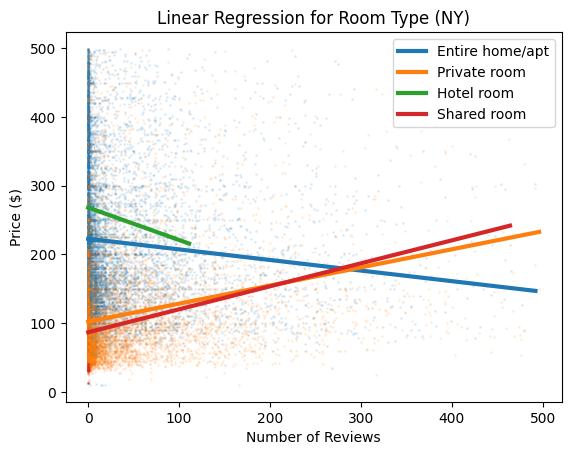

  Residual with distance: [np.float64(10298.20648026131), np.float64(7190.151232111544), np.float64(417.3184408924872), np.float64(1222.4584709259009)]
  Residual with reviews: [np.float64(10898.791901523775), np.float64(7645.256360350792), np.float64(388.85415812097426), np.float64(1204.0091768679588)]


In [33]:
df_airbnb = df_airbnb[df_airbnb["number_of_reviews"] < 500]

rev_residuals = []

for rt in room_types:
    # Select the data for the current room type
    df_sub = df_airbnb[df_airbnb["room_type"] == rt]

    r = df_sub["number_of_reviews"].values
    p = df_sub["price"].values
    n = len(r)

    # I choose linear regression
    B = np.column_stack([np.ones(n), r])

    # method 1: normal equations
    u_normal = np.linalg.solve(B.T @ B, B.T @ p)

    # method 2: QR factorization
    Q, R = np.linalg.qr(B)
    u_qr = np.linalg.solve(R, Q.T @ p)

    # Using the QR coefficients for plotting (they are more stable)
    x_axis = np.linspace(r.min(), r.max(), 100)
    y_poly = u_qr[0] + u_qr[1] * x_axis

    # Plot the curve for the current room type
    plt.plot(x_axis, y_poly, label=f"{rt}", linewidth=3)
    # Scatter the real data points with low opacity
    plt.scatter(r, p, s=1, alpha=0.1)

    res = np.linalg.norm(B @ u_qr - p)
    rev_residuals.append(res)

plt.xlabel("Number of Reviews")
plt.ylabel("Price ($)")
plt.title("Linear Regression for Room Type (NY)")
plt.legend()
plt.show()

# Residui calcolati nei cicli precedenti

print(f"  Residual with distance: {dist_residuals}")
print(f"  Residual with reviews: {rev_residuals}")

### 2d.
I want to plot p(d, r) = u_0 + u_1 * d + u_2 * r considering different room types

In [34]:
residui_2d = []

for rt in room_types:
    df_sub = df_airbnb[df_airbnb["room_type"] == rt]

    d = df_sub["distance"].values
    r = df_sub["number_of_reviews"].values
    p = df_sub["price"].values
    n = len(p)

    # Create the matrix for 2d: p = u0 + u1*d + u2*r
    B_comb = np.column_stack([np.ones(n), d, r])

    # QR factorization for the combined model
    Q, R = np.linalg.qr(B_comb)
    u_comb = np.linalg.solve(R, Q.T @ p)

    # Calculation of the residual for 2d
    res_2d = np.linalg.norm(B_comb @ u_comb - p)
    residui_2d.append(res_2d)

print(f"  Residual with distance and reviews: {residui_2d}")

  Residual with distance and reviews: [np.float64(10331.242372800189), np.float64(7326.528493331077), np.float64(381.7636121693493), np.float64(1188.0988654433347)]


The fitting has slightly improved but we are still considering too few factors.

---

## Assignment 3: Image Deblurring via Variational Regularization

Recovering the original image from a blurred observation is an important problem in image processing and scientific computing. This task allows you to explore linear systems, both direct and iterative solvers. In this exercise, you will model the image deblurring problem as a linear system $Ku=f$, where $K$ represents the blur operator, $f$ is the observed blurred (and possibly noisy) image, and $u$ is the unknown sharp image.

**Tasks**:

1. Dataset and Blur Simulation: Load a standard grayscale image (e.g., `skimage.data.camera()`). Apply a simple convolutional blur (e.g., 3×3 or 5×5 Gaussian-like kernel, see code below).

    *Hint*: use functions `skimage.img_as_float` to read the image, and `scipy.signal.convolve2d` to apply the blurring kernel.

2. Linear System Formulation: Represent the blurring operation as a linear system $Ku=f$, where $f$ is the blurred image, and $u$ is the original image we want to reconstruct by solving the system.

    *Hints*:
   
   - Compute each column $j$-th of matrix $K$ by applying the `convolve2d` operation on a basis vector (which has component $1$ only at column $j$ and $0$ everywhere else).
   
    - To be precise, $f$ and $u$ are the *vectorized* images (if the image has shape $(N, N)$, the vectorized image has shape $(N^2, 1)$).
   
4. Direct Solver: Solve the linear system using a direct solver ($LU$ factorization).
 
   *Hint*: consider applying methods for sparse matrices (built-in `scipy` methods).
   
5. Iterative Solvers: Implement and test Jacobi and Gauss–Seidel iterative methods.
Optionally, use Conjugate Gradient ($CG$) if the system is symmetric and positive definite.

6. Compare the methods in terms of convergence rates and number of iterations: plot the residual vs iterations, and print the accuracy of the obtained images in terms of the mean squared error with respect to the original one.
   
7. **Bonus**: repeat the same analysis adding also a Gaussian noise to the blurred image $f$. How do the methods perform now?


**Suggestion**: always solve the problems depending on the computational power of your laptop. The image might be too big: for example `skimage.data.camera()` produces an image of size $(512, 512)$, and the matrix $K$ would have size $(512^2, 512^2)$. Consider downsampling it, for example considering an image of size $(64, 64)$ or $(32, 32)$.

In [35]:
import numpy as np

# Strong Gaussian kernel
def gaussian_kernel(size=21, sigma=2.):
    ax = np.arange(-size//2 + 1., size//2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return kernel / kernel.sum()

kernel = gaussian_kernel(size=21, sigma=1.)

## SOLUTION

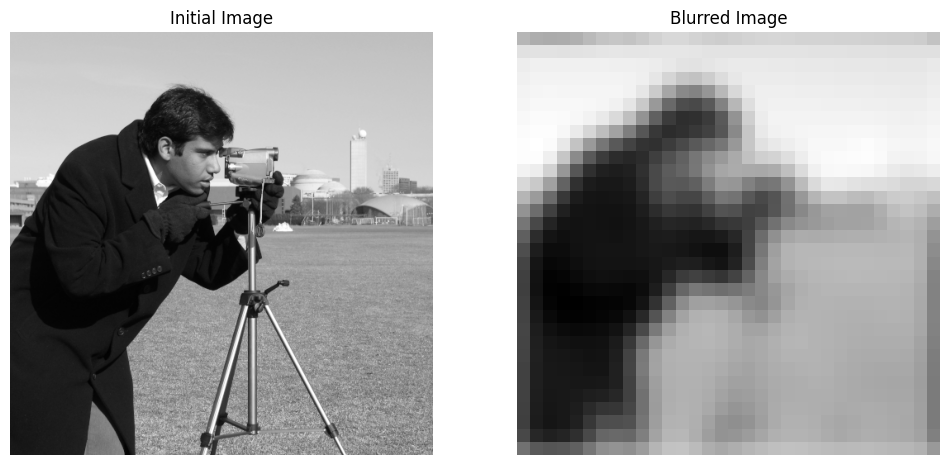

In [36]:
# Standard image from skimage
image_raw = data.camera()
# Convert the image to float in the range [0, 1]
image_float = img_as_float(image_raw)

# Strong Gaussian kernel
def gaussian_kernel(size=21, sigma=2.0):
    ax = np.arange(-size // 2 + 1.0, size // 2 + 1.0)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))
    return kernel / kernel.sum()

# Reduce the image size to 32x32 for faster processing
n = 32
image_sharp = transform.resize(image_float, (n, n), anti_aliasing=True)

# Impose the Gaussian blur on the image with 5x5 kernel and sigma=1
kernel = gaussian_kernel(size=5, sigma=1.0)
image_blurred = convolve2d(image_sharp, kernel, mode="same", boundary="wrap")

# VISUALIZATION

plt.figure(figsize=(12, 6))

# Initial image
plt.subplot(1, 2, 1)
plt.imshow(image_raw, cmap="gray")
plt.title("Initial Image")
plt.axis("off")

# Blurred image
plt.subplot(1, 2, 2)
plt.imshow(image_blurred, cmap="gray")
plt.title("Blurred Image")
plt.axis("off")

# Mostra effettivamente la finestra con i grafici
plt.show()

### 2.

In [37]:
# Number of pixels in the image
N = n * n
# Create the sparse matrix A of size N x N
A = sparse.lil_matrix((N, N))

for j in range(N):
    # Creating the canonical basis vector e_j
    e_j = np.zeros(N)
    e_j[j] = 1.0

    # Transforming the vector into a 2D matrix (n x n)
    # to apply the convolution operation
    e_j_2d = e_j.reshape((n, n))

    # Blurring every single pixel (the j-th one) to see how it affects the whole image
    col_blurred_2d = convolve2d(e_j_2d, kernel, mode="same", boundary="wrap")

    # The result of the blurring (2D matrix) is "flattened"
    # and becomes the j-th column of our matrix A
    A[:, j] = col_blurred_2d.reshape((N, 1))

# We convert to CSC format for efficiency in subsequent operations
A = A.tocsc()
b = image_blurred.flatten()

# BONUS ADD (last task): Adding noise to the blurred image and testing the solvers again

# # Choosing a noise level (standard deviation)
# sigma_noise = 0.02
# # Generating random Gaussian noise
# noise = sigma_noise * np.random.normal(size=b.shape)

# # Creating the noisy blurred image
# b = b + noise


### 3.

In [38]:
# Solving the linear system Ax = b using LU factorization

# The splu function from SciPy returns an object containing the L and U matrices
LU_obj = splu(A)
x_LU = LU_obj.solve(b)

### 4.

In [39]:
# Choosing parameters for the iterative solvers
max_iters = 200
tolerance = 1e-6

# We have to convert A to a dense format for Jacobi/GS because utils.py doesn't use sparse matrices
A_dense = A.toarray()

# 1. Jacobi
x_jac, it_jac, res_jac = jacobi(A_dense, b, max_iter=max_iters, tol=tolerance)

# 2. Gauss-Seidel
x_gs, it_gs, res_gs = gauss_seidel(A_dense, b, max_iter=max_iters, tol=tolerance)

# 3. Conjugate Gradient
x_cg, it_cg, res_cg = conj_gradient(A_dense, b, max_iter=max_iters, tol=tolerance)

print(f"Jacobi: iterations = {it_jac}, residual = {res_jac[-1]}")
print(f"Gauss-Seidel: iterations = {it_gs}, residual = {res_gs[-1]}")
print(f"Conjugate Gradient: iterations = {it_cg}, residual = {res_cg[-1]}")

Jacobi: iterations = 200, residual = 7.752890263357925e+143
Gauss-Seidel: iterations = 200, residual = 1.1120213542808506e-05
Conjugate Gradient: iterations = 121, residual = 8.560559189962827e-07


We see the Jacobi method is the only one not converging.
### 5.

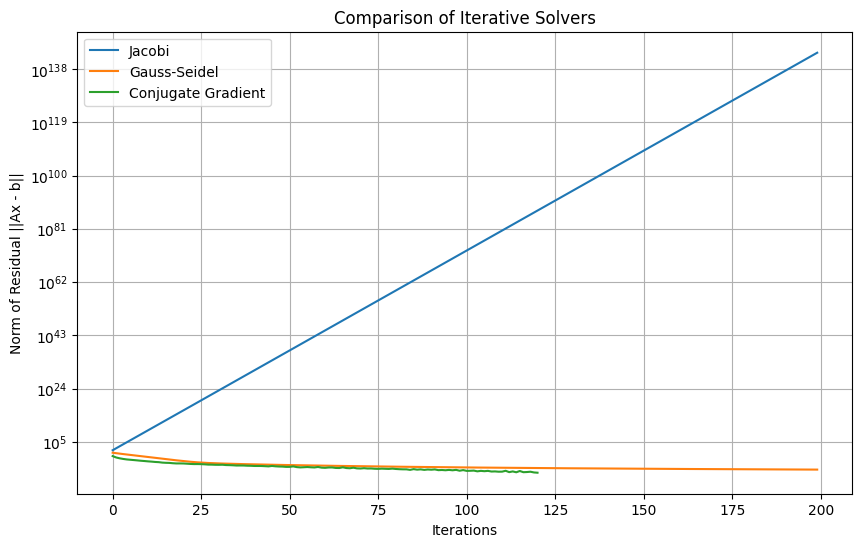

------------------------------
Method               | MSE       
------------------------------
Direct (LU)          | 0.000000
Jacobi               | 5.87e+284
Gauss-Seidel         | 0.000000
Conj. Gradient       | 0.000000
------------------------------


In [40]:
# Plotting the convergence of the iterative solvers
plt.figure(figsize=(10, 6))
plt.semilogy(res_jac, label=f"Jacobi")
plt.semilogy(res_gs, label=f"Gauss-Seidel")
plt.semilogy(res_cg, label=f"Conjugate Gradient")

plt.xlabel("Iterations")
plt.ylabel("Norm of Residual ||Ax - b||")
plt.title("Comparison of Iterative Solvers")
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

# Ricorda: x_LU viene dal punto 3 (LU), gli altri dal punto 4
mse_LU = mean_squared_error(image_sharp.flatten(), x_LU)
mse_jac = mean_squared_error(image_sharp.flatten(), x_jac)
mse_gs = mean_squared_error(image_sharp.flatten(), x_gs)
mse_cg = mean_squared_error(image_sharp.flatten(), x_cg)

print("-" * 30)
print(f"{'Method':<20} | {'MSE':<10}")
print("-" * 30)
print(f"{'Direct (LU)':<20} | {mse_LU:.6f}")
print(f"{'Jacobi':<20} | {mse_jac:.2e}")
print(f"{'Gauss-Seidel':<20} | {mse_gs:.6f}")
print(f"{'Conj. Gradient':<20} | {mse_cg:.6f}")
print("-" * 30)

### 6.
To add a Gaussian noise to the blurred image  we have to add the commented code at the task 2 and run all the code again.